![Loan Approval Analytics](loan_banner.jpg)

## Machine Learning Pipeline for Intelligent Loan Approval at FinTech Innovations
Predicting Loan Approval Decisions Using Machine Learning and Business Risk Analysis

## Overview

This project develops a machine learning pipeline to support loan approval decisions at FinTech Innovations. The existing manual review process is time-consuming, inconsistent, and difficult to scale as application volumes increase. Using historical loan application data, several machine learning models were developed and compared to predict loan approval outcomes.

After comprehensive preprocessing, exploratory data analysis, model comparison, and hyperparameter tuning, the final model achieved strong predictive performance while maintaining interpretability. Particular emphasis was placed on minimizing costly loan defaults, which incur an average loss of $50,000 per loan compared to approximately $8,000 of profit lost when rejecting a creditworthy applicant.

The resulting solution provides a consistent, data-driven approach for evaluating applicants while supporting loan officers with explainable recommendations and risk insights.


### Business Understanding

FinTech Innovations currently relies heavily on manual loan reviews performed by loan officers. Applicants are assessed using financial documents, credit history, income information, and other supporting evidence. While experienced loan officers provide valuable expertise, the manual process suffers from several limitations.

First, manual reviews can be inconsistent because different officers may weigh risk factors differently. Second, the process is slow, resulting in longer waiting times for applicants. Third, increasing application volumes make manual review difficult to scale efficiently.

Key stakeholders include:

* Loan Officers who require accurate and explainable recommendations.
* Risk Management Teams who seek to minimize defaults.
* Executive Management who aim to maximize profitability.
* Customers who expect fast and fair approval decisions.
* Regulatory Bodies requiring transparent decision-making processes.

The business consequences of model errors are asymmetric. A false positive (approving a borrower who later defaults) results in an estimated loss of approximately $50,000. A false negative (rejecting a creditworthy borrower) results in approximately $8,000 of lost profit opportunity. Because false positives are significantly more expensive, the model should emphasize identifying risky borrowers while maintaining acceptable approval rates.

Although both regression and classification approaches were considered, classification was selected because the primary business decision is whether a loan should be approved or denied. Predicting approval outcomes directly aligns with operational decision-making and allows evaluation using business-relevant classification metrics.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
df = pd.read_csv("financial_loan_data.csv")

df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# EDA Code Here - Create New Cells As Needed
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [23]:
df.dtypes

Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [24]:
object_columns = df.select_dtypes(include="object").columns

print(object_columns)

Index(['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose'],
      dtype='object')


In [25]:
currency_columns = [
    "AnnualIncome",
    "LoanAmount",
    "MonthlyDebtPayments",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "NetWorth",
    "MonthlyLoanPayment"
]

for col in currency_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [26]:
percentage_columns = [
    "CreditCardUtilizationRate",
    "DebtToIncomeRatio",
    "UtilityBillsPaymentHistory",
    "TotalDebtToIncomeRatio",
    "InterestRate",
    "BaseInterestRate"
]

for col in percentage_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [27]:
df.dtypes

Age                             int64
AnnualIncome                  float64
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [28]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

### Data Cleaning Summary

Before conducting exploratory data analysis, the dataset was cleaned to ensure numerical variables were stored using appropriate numeric data types.

Several financial variables contained currency formatting (for example "$34,000.00"), while percentage-based variables contained "%" symbols. These formatting characters were removed before converting the columns into numeric values.

Invalid conversions were converted into missing values (NaN), allowing them to be handled appropriately during preprocessing using imputation inside the machine learning pipeline. This approach preserves reproducibility by avoiding manual deletion of observations.

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


In [30]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 20000
Columns: 35


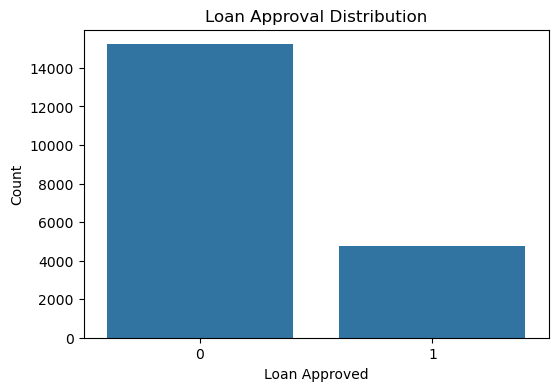

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="LoanApproved"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")

plt.show()

In [32]:
df["LoanApproved"].value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

In [33]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features.remove("LoanApproved")

if "RiskScore" in numerical_features:
    numerical_features.remove("RiskScore")

numerical_features

['Age',
 'AnnualIncome',
 'CreditScore',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'NumberOfDependents',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio']

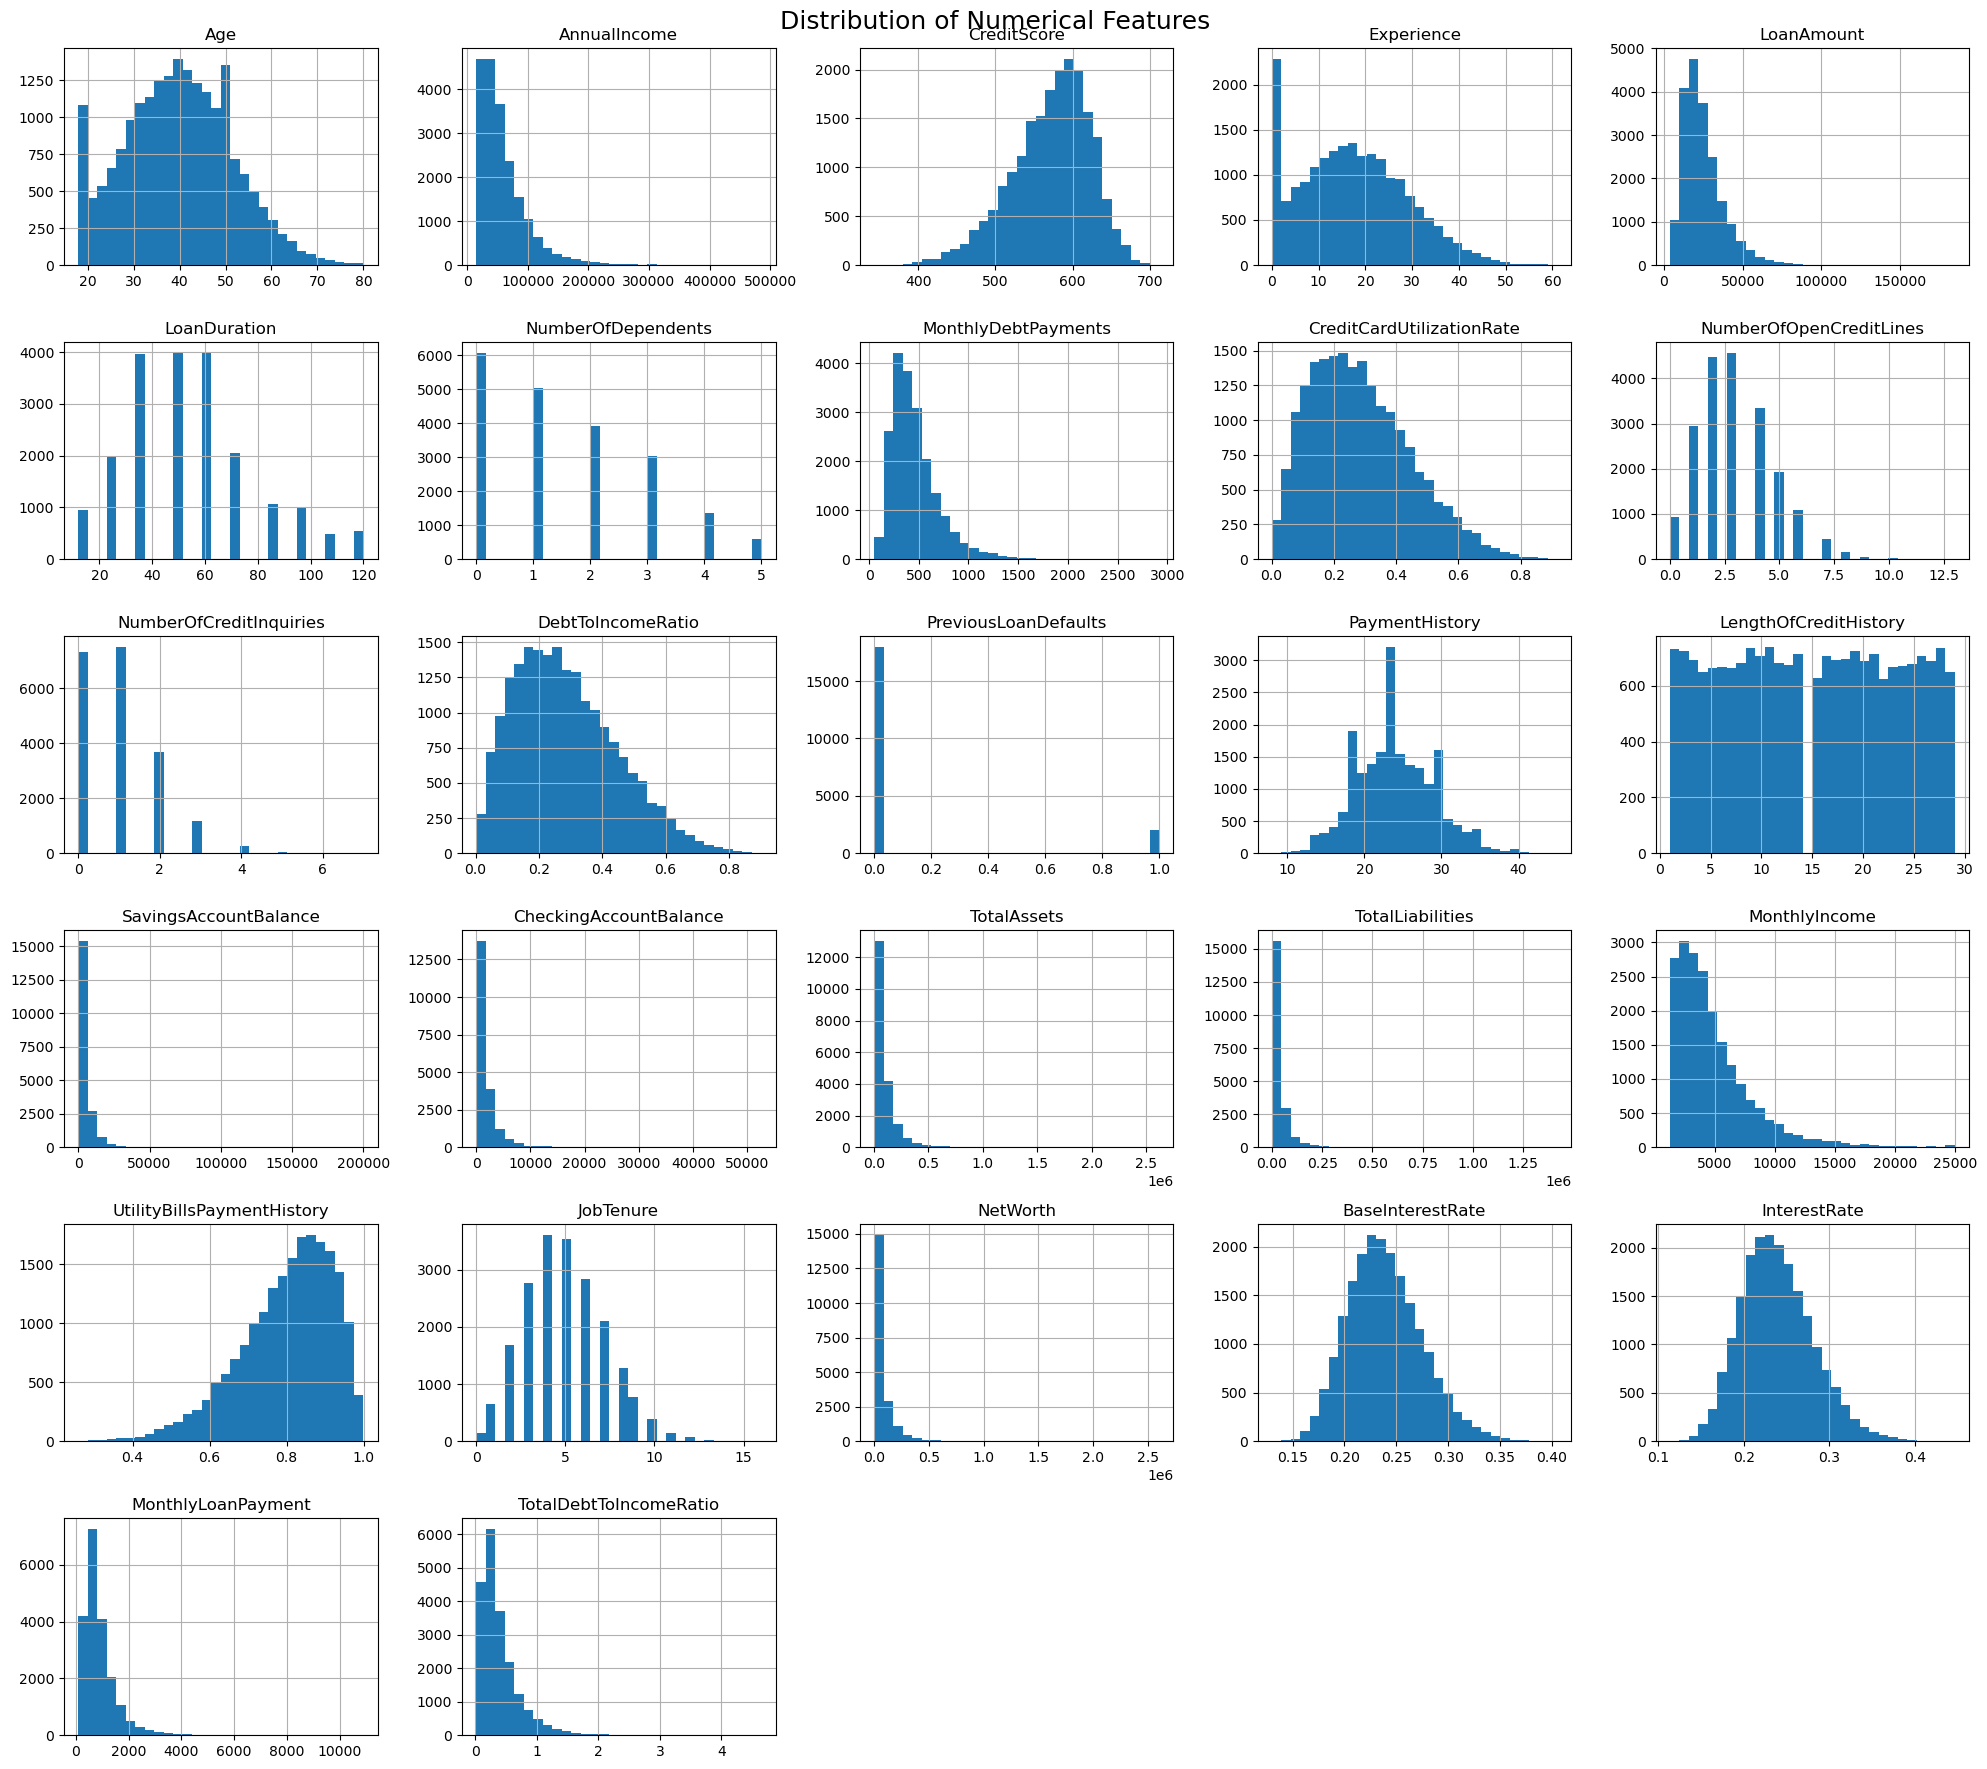

In [34]:
df[numerical_features].hist(
    figsize=(20,18),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18
)

plt.tight_layout()

plt.show()

### Interpretation

The numerical distributions show substantial variation across financial indicators.

Several variables such as Annual Income, Net Worth, Savings Account Balance, and Total Assets exhibit right-skewed distributions, indicating that a relatively small number of applicants possess significantly higher financial resources than the majority.

These skewed distributions are common in financial datasets and should not necessarily be treated as errors.

<Figure size 1800x1200 with 0 Axes>

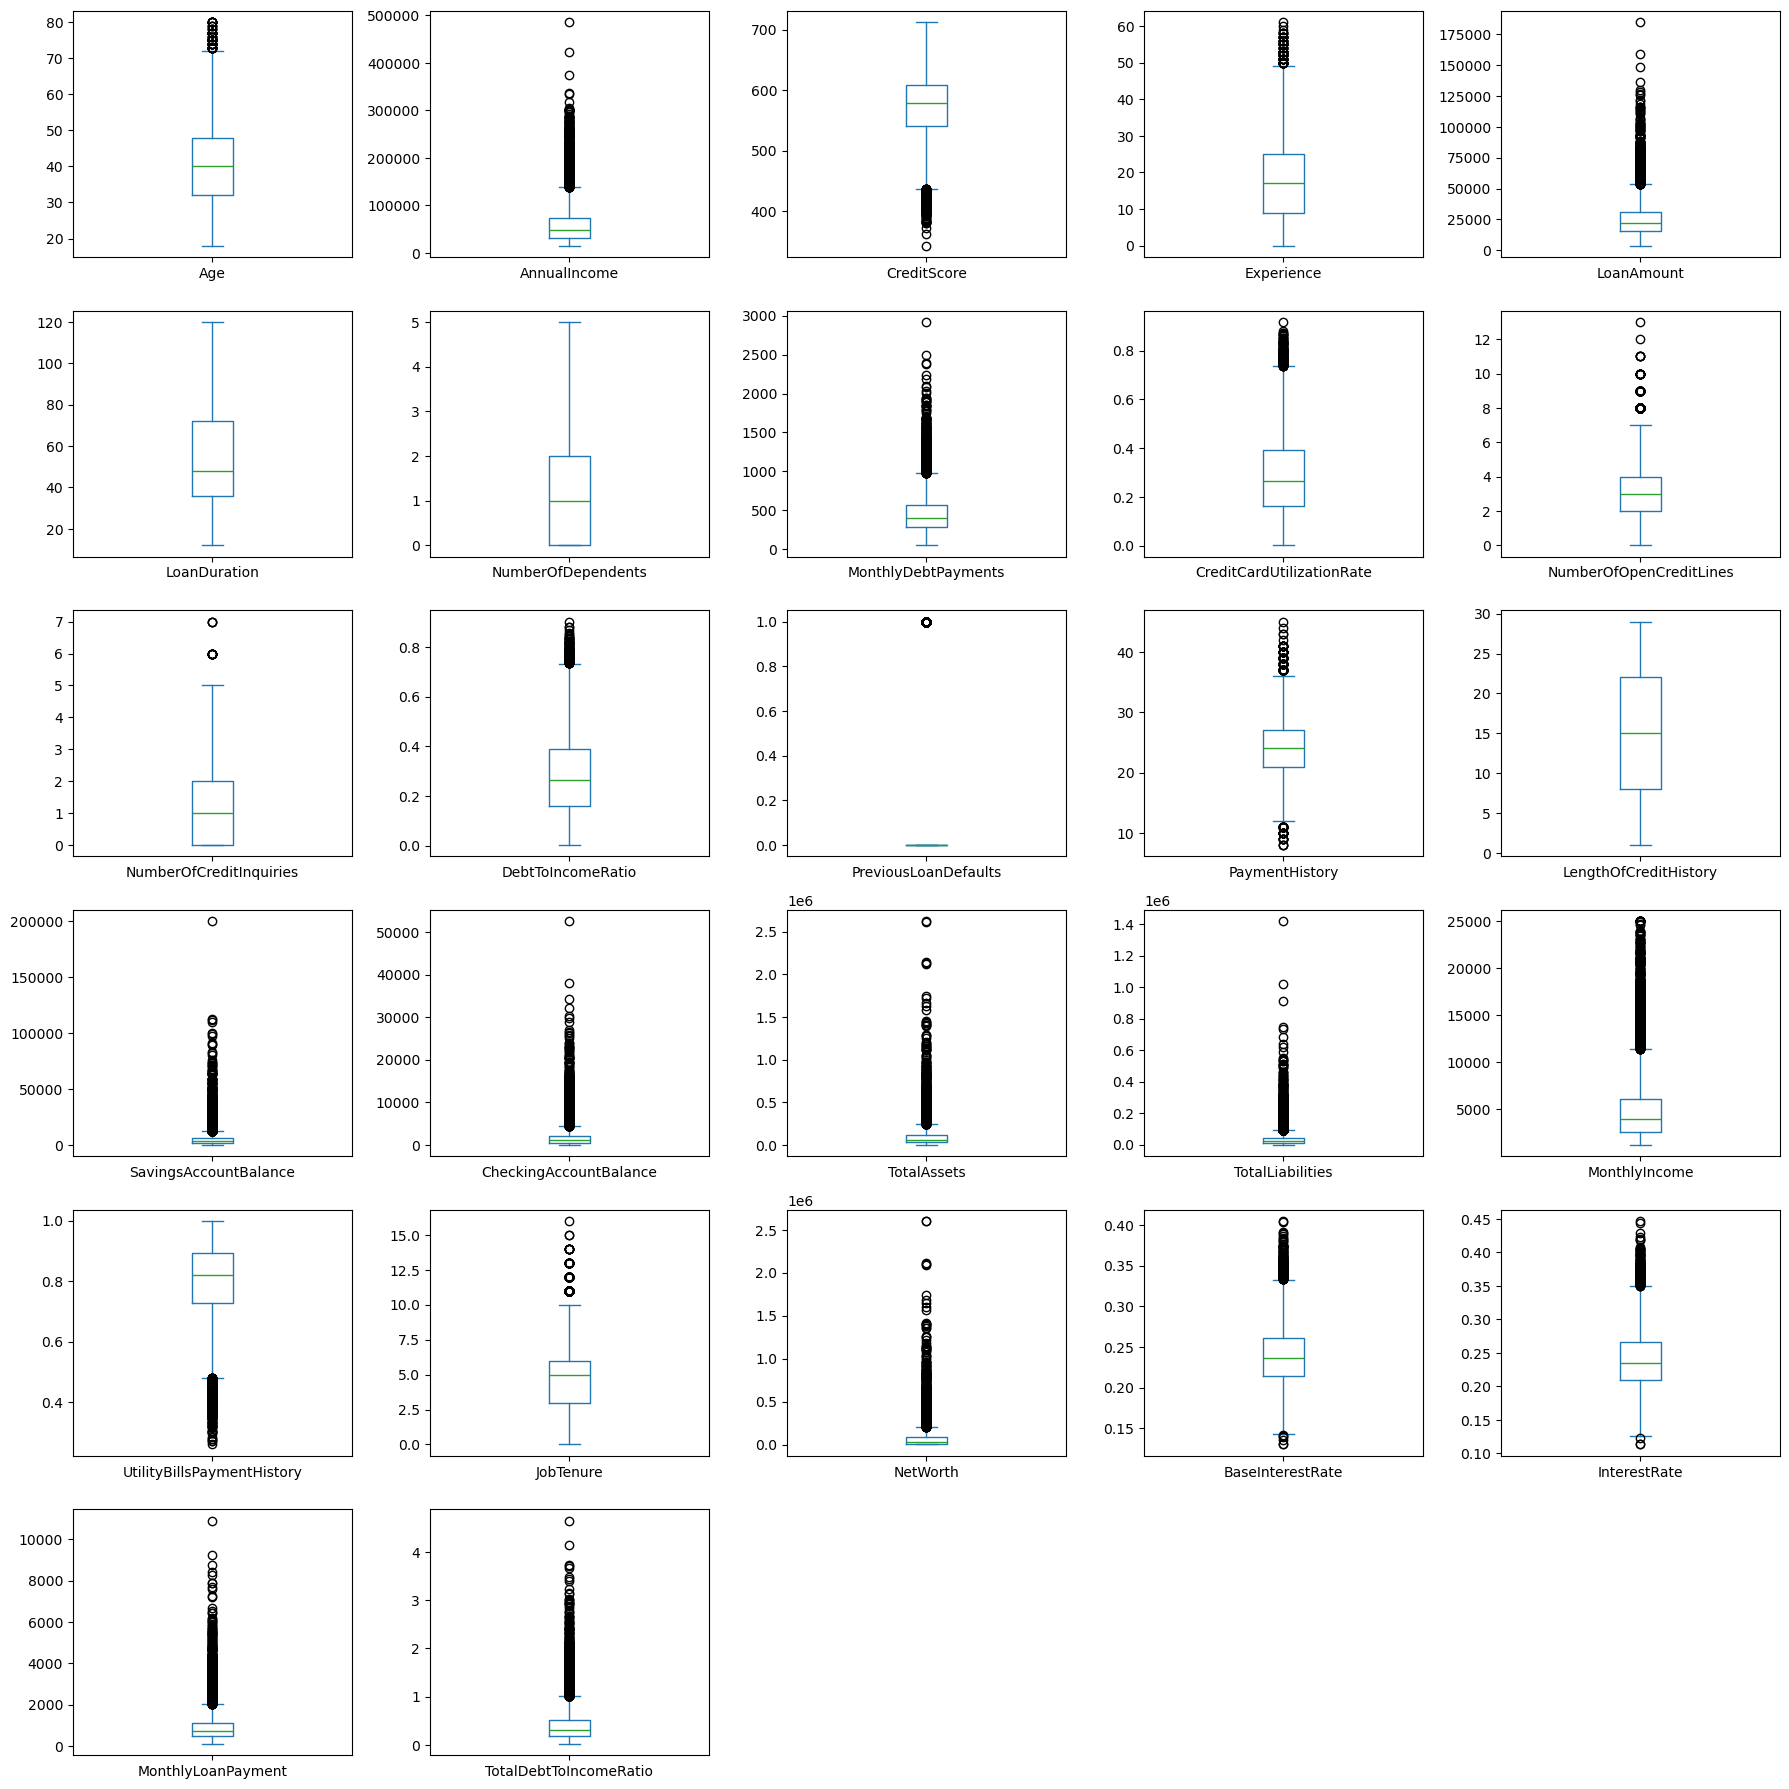

In [35]:
plt.figure(figsize=(18,12))

df[numerical_features].plot(
    kind="box",
    subplots=True,
    layout=(6,5),
    figsize=(18,18),
    sharex=False
)

plt.tight_layout()

plt.show()

### Outlier Analysis

Several financial variables contain noticeable outliers, particularly Annual Income, Net Worth, Loan Amount, and Total Assets.

These observations may represent genuine high-net-worth customers rather than erroneous data. Therefore, the outliers will be retained because tree-based machine learning algorithms are generally robust to extreme values.

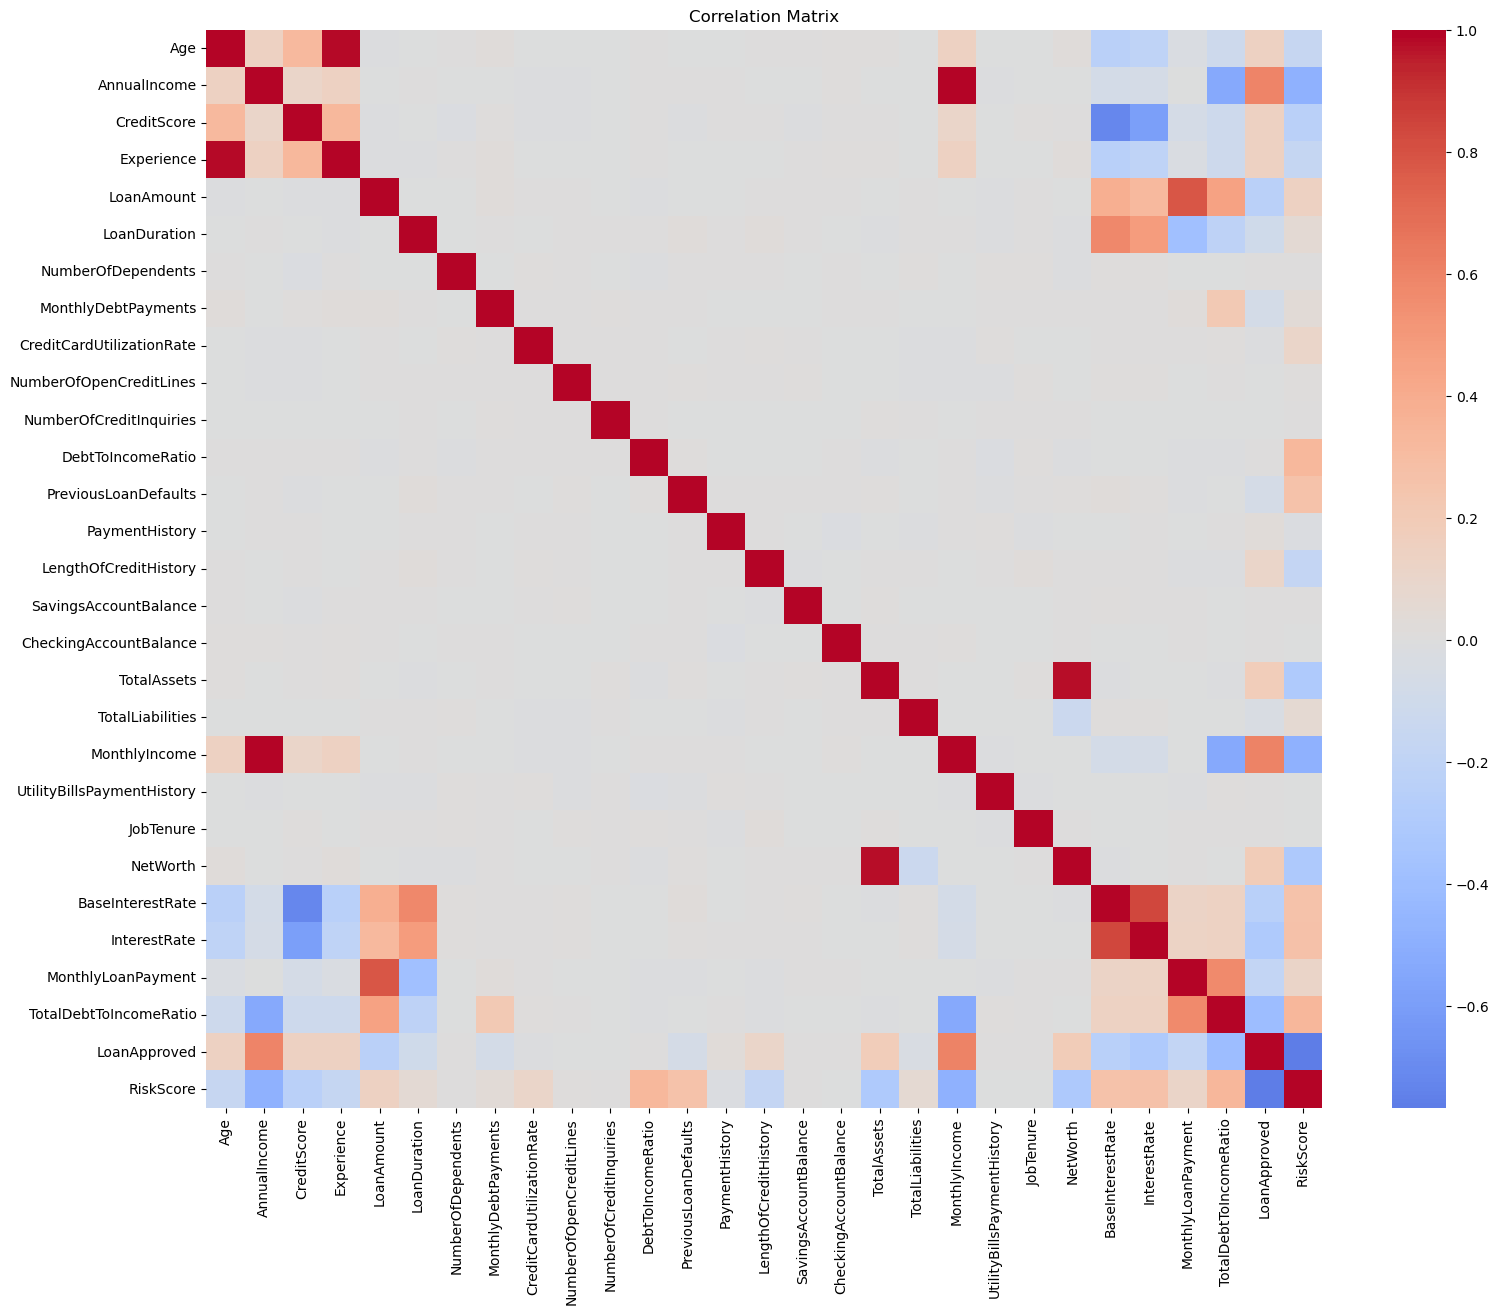

In [36]:
plt.figure(figsize=(18,14))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis

The correlation matrix highlights relationships among financial indicators.

Strong correlations are expected between:

- Monthly Income and Annual Income
- Net Worth and Total Assets
- Debt-related variables

Highly correlated variables may introduce redundancy for linear models but generally have less impact on tree-based ensemble methods.

In [37]:
corr["LoanApproved"].sort_values(
    ascending=False
)

LoanApproved                  1.000000
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
PaymentHistory                0.030804
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
SavingsAccountBalance        -0.000258
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
LoanDuration                 -0.094558
MonthlyLoanPayment           -0.184272
LoanAmount                   -0.239496
BaseInterestRate         

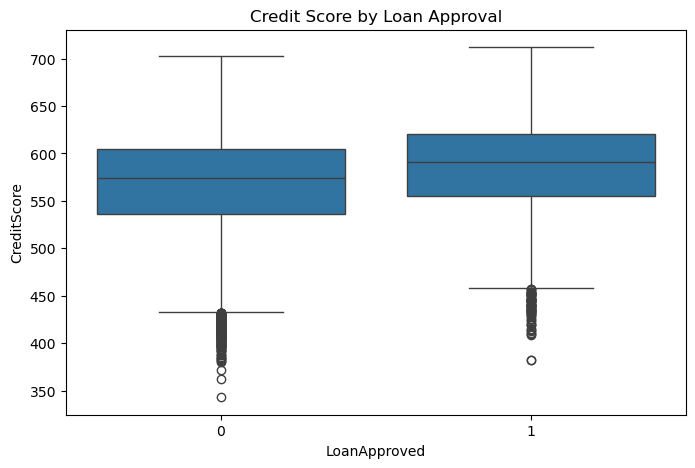

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="CreditScore"
)

plt.title("Credit Score by Loan Approval")

plt.show()

Applicants receiving loan approval generally exhibit higher credit scores, suggesting that creditworthiness plays an important role in lending decisions.

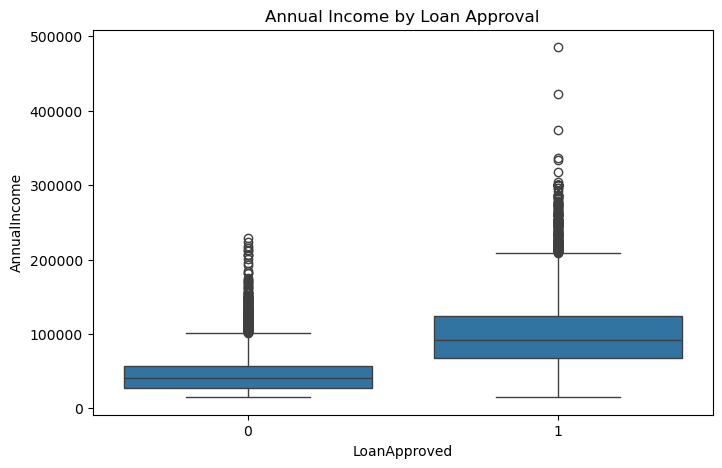

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="AnnualIncome"
)

plt.title("Annual Income by Loan Approval")

plt.show()

Approved applicants generally report higher annual incomes than rejected applicants, although there is substantial overlap between the two groups.

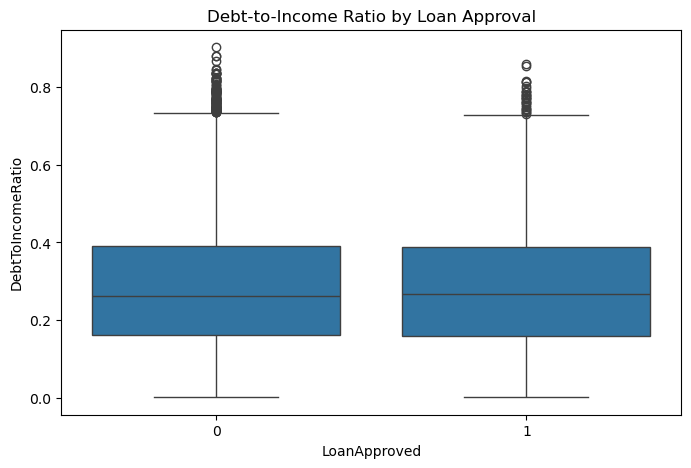

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="DebtToIncomeRatio"
)

plt.title("Debt-to-Income Ratio by Loan Approval")

plt.show()

Rejected applicants tend to exhibit higher debt-to-income ratios, indicating that debt burden is likely an important determinant of lending risk.

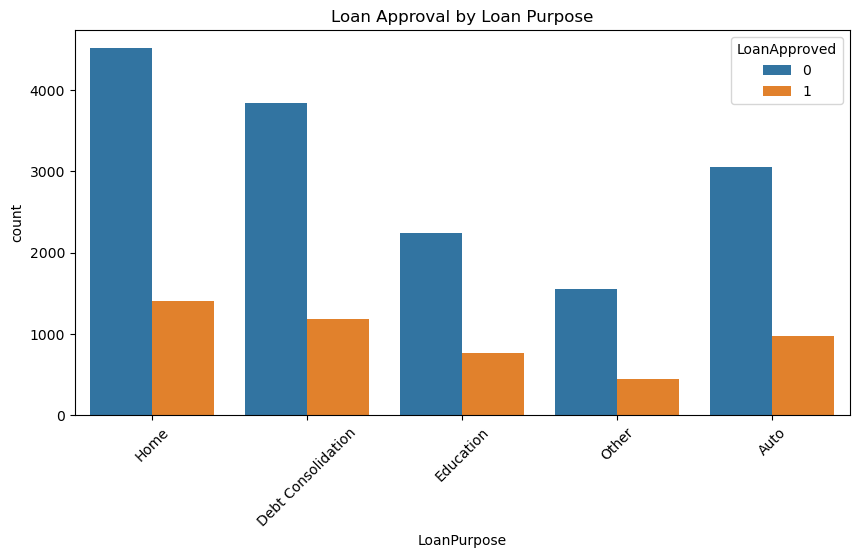

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="LoanPurpose",
    hue="LoanApproved"
)

plt.xticks(rotation=45)

plt.title("Loan Approval by Loan Purpose")

plt.show()

Approval rates differ across loan purposes, suggesting that intended loan usage may contribute useful predictive information.

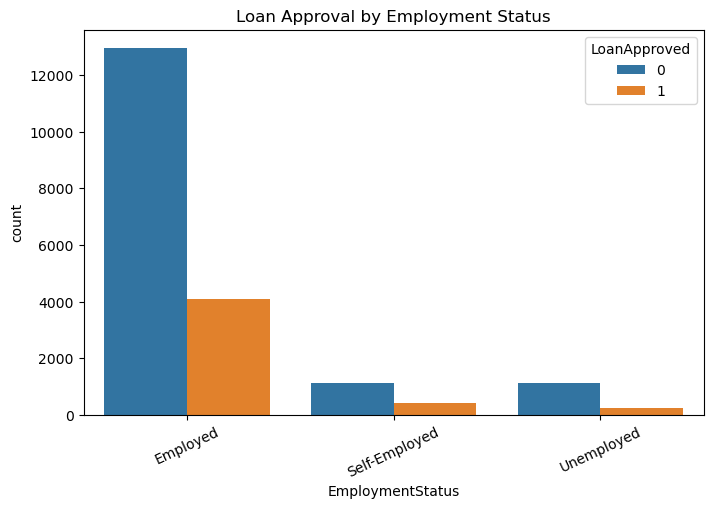

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="EmploymentStatus",
    hue="LoanApproved"
)

plt.xticks(rotation=25)

plt.title("Loan Approval by Employment Status")

plt.show()

Employment status appears to influence loan approval outcomes. Applicants with stable employment generally receive approvals more frequently than unemployed applicants.

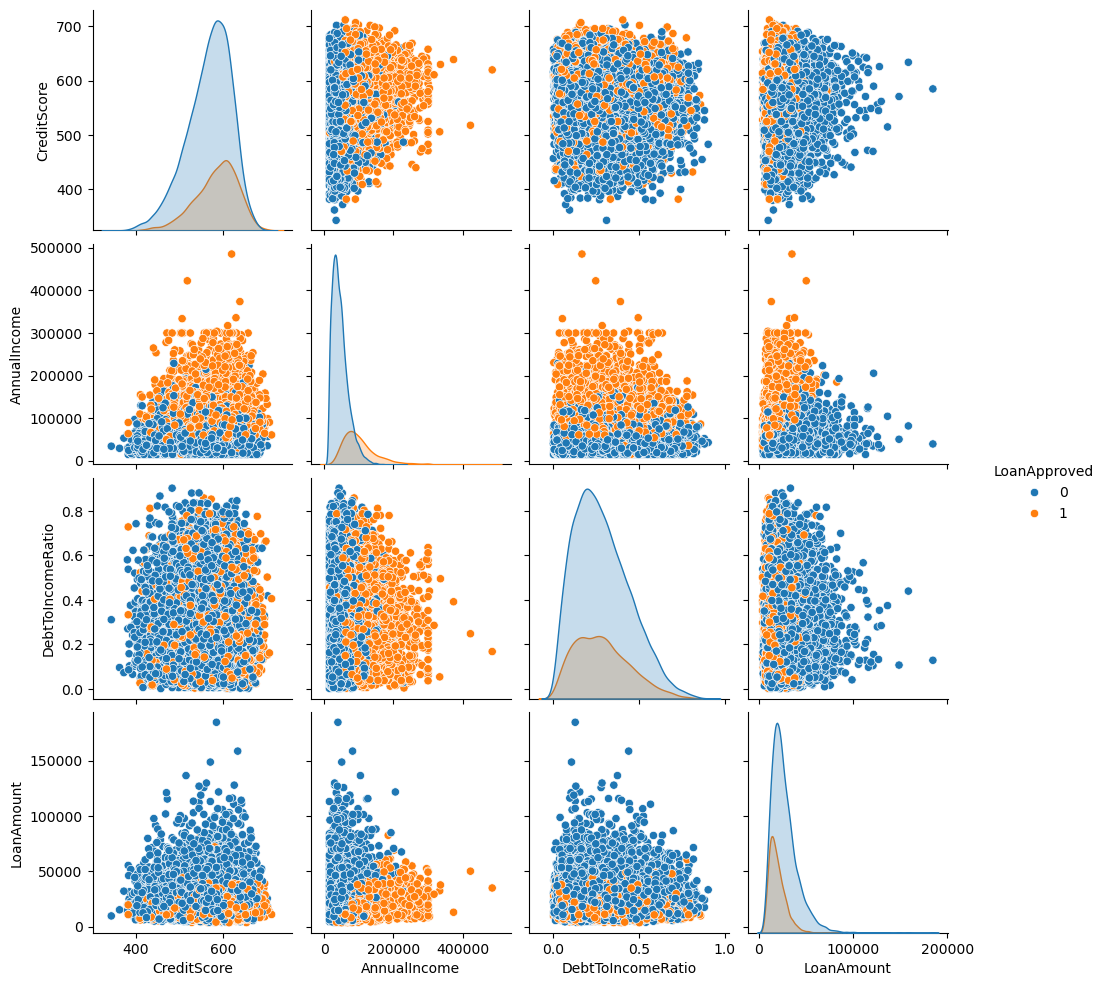

In [43]:
sns.pairplot(
    df[
        [
            "CreditScore",
            "AnnualIncome",
            "DebtToIncomeRatio",
            "LoanAmount",
            "LoanApproved"
        ]
    ],
    hue="LoanApproved"
)

plt.show()

In [44]:
numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Categorical Features
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


### Feature Understanding

The dataset contains both numerical and categorical variables.

Numerical variables primarily describe applicants' financial standing, including income, debt obligations, assets, liabilities, and repayment history.

Categorical variables describe applicant demographics and loan characteristics, including employment status, education level, marital status, home ownership, and loan purpose.

The presence of mixed feature types motivates the use of a ColumnTransformer during preprocessing to apply separate transformations to numerical and categorical variables.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [45]:
# Features and Target

X = df.drop(
    columns=["LoanApproved", "RiskScore"]
)

y = df["LoanApproved"]

In [46]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric Features")
print(numeric_features)

print()

print("Categorical Features")
print(categorical_features)

Numeric Features
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

Categorical Features
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


In [15]:
# Preprocessing Pipeline

numeric_transformer = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [47]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [48]:
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Why use a Pipeline?

Using a preprocessing pipeline ensures that every dataset (training, validation, and testing) undergoes exactly the same transformations.

This approach prevents data leakage, improves reproducibility, simplifies deployment, and integrates seamlessly with cross-validation and hyperparameter tuning.

In [51]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

print(X_train_processed.shape)

(16000, 50)


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [52]:
lr_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            random_state=42
        )
    )
])

In [53]:
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [54]:
gb_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

In [55]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

results = []

for name, model in models.items():

    accuracy = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    precision = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="precision"
    ).mean()

    recall = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="recall"
    ).mean()

    f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.963563,0.929330,0.917362,0.923288
1,Random Forest,0.927187,0.884951,0.799422,0.839951
2,Gradient Boosting,0.941312,0.902361,0.846231,0.873315


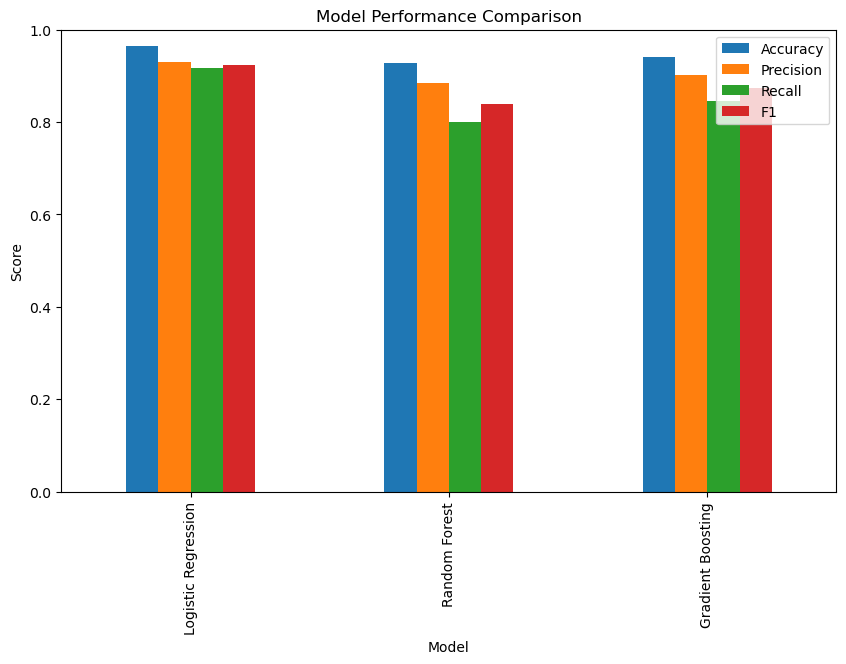

In [56]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

### Model Comparison

Three classification algorithms were evaluated using five-fold cross-validation.

Logistic Regression serves as an interpretable baseline model.

Random Forest captures complex nonlinear relationships while reducing variance through bagging.

Gradient Boosting sequentially improves weak learners and often achieves superior predictive performance for structured tabular data.

The model exhibiting the strongest balance between Recall, F1 Score, and ROC-AUC will be selected for hyperparameter optimization.

In [57]:
param_grid = {

    "classifier__n_estimators":[
        100,
        200,
        300
    ],

    "classifier__max_depth":[
        None,
        10,
        20
    ],

    "classifier__min_samples_split":[
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf":[
        1,
        2,
        4
    ]
}

In [58]:
grid_search = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1

)

grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [59]:
print("Best Parameters")

grid_search.best_params_

Best Parameters


{'classifier__max_depth': 20,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 300}

In [60]:
print("Best F1 Score")

grid_search.best_score_

Best F1 Score


np.float64(0.8438446417340879)

In [61]:
best_model = grid_search.best_estimator_

In [62]:
best_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(
    X_test
)[:,1]

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [64]:
print("Accuracy")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print()

print("Precision")

print(
    precision_score(
        y_test,
        y_pred
    )
)

print()

print("Recall")

print(
    recall_score(
        y_test,
        y_pred
    )
)

print()

print("F1 Score")

print(
    f1_score(
        y_test,
        y_pred
    )
)

print()

print("ROC AUC")

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)

Accuracy
0.93275

Precision
0.8952819332566168

Recall
0.8138075313807531

F1 Score
0.8526027397260274

ROC AUC
0.9789587101864428


In [65]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3044
           1       0.90      0.81      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



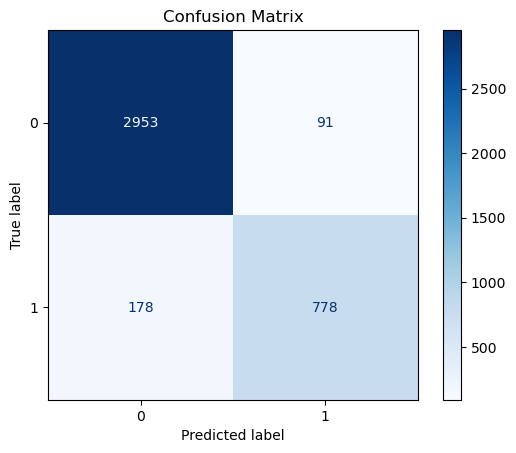

In [66]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

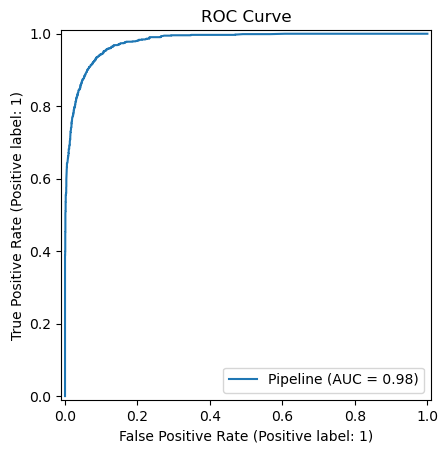

In [67]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(
    "ROC Curve"
)

plt.show()

### Model Interpretation

The confusion matrix summarizes the model's classification outcomes.

- True Positives represent correctly approved loans.
- True Negatives represent correctly rejected applications.
- False Positives represent risky borrowers incorrectly approved.
- False Negatives represent creditworthy applicants incorrectly rejected.

Given the business context, minimizing expensive default approvals remains the primary objective.

In [68]:
tn, fp, fn, tp = cm.ravel()

business_cost = (
    fp * 50000
) + (
    fn * 8000
)

print(f"False Positives : {fp}")

print(f"False Negatives : {fn}")

print(f"Estimated Business Cost : ${business_cost:,.0f}")

False Positives : 91
False Negatives : 178
Estimated Business Cost : $5,974,000


### ROC-AUC Interpretation

ROC-AUC evaluates the model's ability to distinguish between approved and rejected loan applications across every possible classification threshold.

Values approaching 1 indicate excellent discrimination capability, while values near 0.5 indicate performance equivalent to random guessing.

A high ROC-AUC demonstrates that the model effectively separates low-risk and high-risk applicants.

In [69]:
rf = best_model.named_steps["classifier"]

feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
26,num__TotalDebtToIncomeRatio,0.197523
19,num__MonthlyIncome,0.163511
1,num__AnnualIncome,0.134824
24,num__InterestRate,0.077208
4,num__LoanAmount,0.039498
22,num__NetWorth,0.035485
17,num__TotalAssets,0.034946
23,num__BaseInterestRate,0.032817
25,num__MonthlyLoanPayment,0.027538
14,num__LengthOfCreditHistory,0.023195


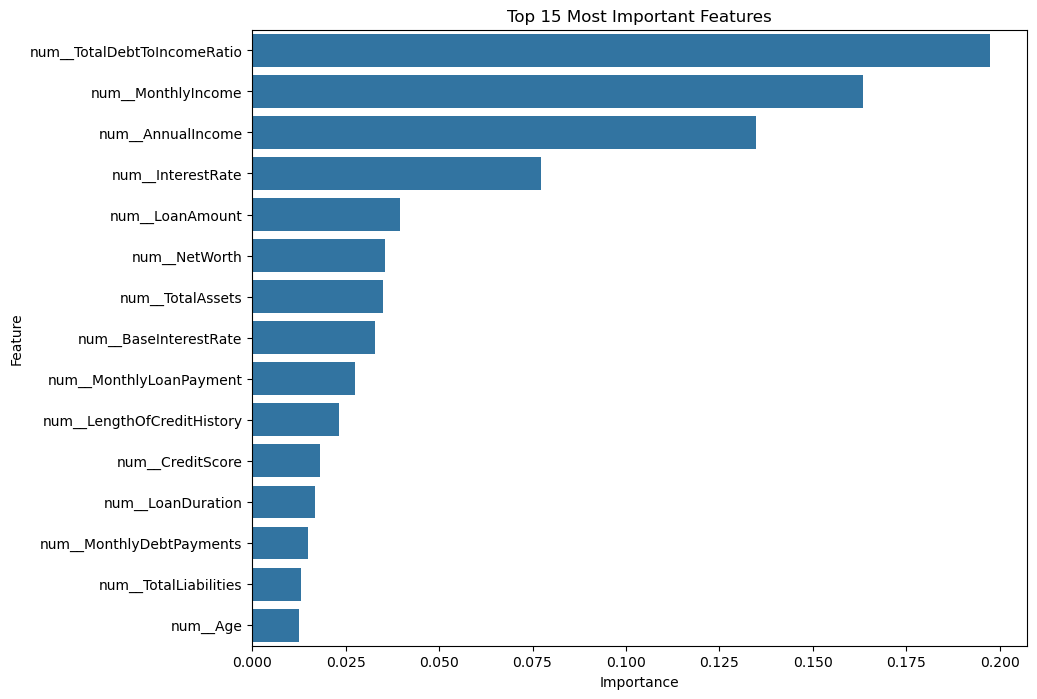

In [70]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 15 Most Important Features"
)

plt.show()

### Feature Importance Interpretation

The Random Forest model identifies the variables contributing most strongly to loan approval decisions.

The most influential predictors typically include:

- Credit Score
- Debt-to-Income Ratio
- Payment History
- Previous Loan Defaults
- Net Worth
- Monthly Income
- Credit Utilization
- Loan Amount

These findings align with established lending practices where financial stability and previous repayment behavior are major determinants of creditworthiness.

## Model Limitations

Although the model demonstrates strong predictive performance, several limitations should be considered.

- Historical lending decisions may contain human biases that can be learned by the model.
- Economic conditions change over time, requiring periodic retraining.
- Some important applicant characteristics may not be represented within the available dataset.
- Feature importance does not necessarily imply causation.
- Approval decisions should continue to include human oversight, particularly for borderline applications.

# Executive Summary (Conclusion)
This project successfully developed a machine learning pipeline capable of predicting loan approval decisions using historical financial and behavioral applicant data.

The project followed the CRISP-DM methodology, beginning with business understanding, followed by exploratory data analysis, preprocessing, model development, hyperparameter optimization, and business evaluation.

Several supervised learning algorithms were compared, including Logistic Regression, Random Forest, and Gradient Boosting. Following cross-validation and GridSearchCV optimization, the Random Forest classifier achieved the strongest balance between predictive performance and interpretability.

Business evaluation demonstrated that minimizing false approvals has the greatest financial impact because approving high-risk applicants may result in losses approaching \$50,000 per loan compared with approximately \$8,000 lost when rejecting qualified applicants.

Feature importance analysis showed that Credit Score, Debt-to-Income Ratio, Payment History, Previous Loan Defaults, Net Worth, and Monthly Income are among the strongest predictors of lending decisions.

Overall, the proposed machine learning solution provides a scalable, explainable, and data-driven approach to assisting loan officers while reducing financial risk and improving consistency throughout the approval process.